Importing Dependencies


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics


Importing the Boston House Price Dataset

In [13]:
house_price_dataset = sklearn.datasets.fetch_california_housing()

In [14]:
#Loading data to a pandas dataframe
house_price_df = pd.DataFrame(house_price_dataset.data, columns=house_price_dataset.feature_names)

#print first 5 rows of the dataset
house_price_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [15]:
#add the target (price) to the dataframe
house_price_df['price'] = house_price_dataset.target

In [16]:
house_price_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
#checking the number of rows and columns in the dataframe
house_price_df.shape

(20640, 9)

In [18]:
#check for missing values
house_price_df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


In [19]:
#statistical measures of the dataset
house_price_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Understanding the correlation between various variables in the dataset

1. Positive Correlation

2. Negative Correlation

In [20]:
correlation = house_price_df.corr()

<Axes: >

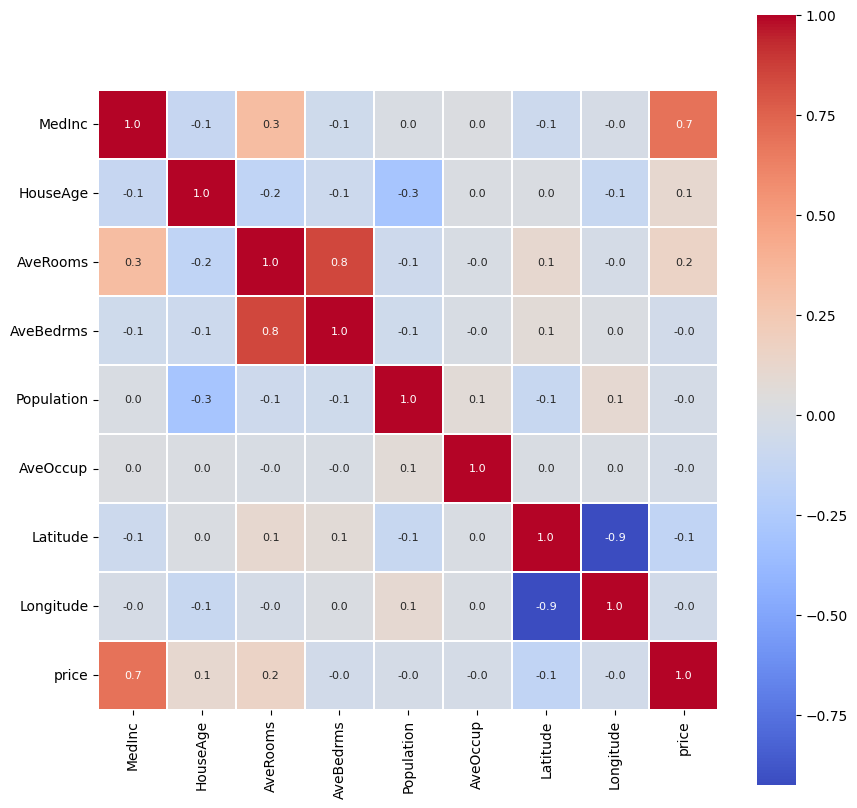

In [27]:
#constructing a heatmap to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True,linewidth=.2,linecolor='white', fmt='.1f', annot=True, annot_kws={'size':8}, cmap='coolwarm')

Splitting the data and target

In [30]:
X = house_price_df.drop(['price','Longitude','Latitude'], axis=1)
y = house_price_df.price

In [31]:
print(X)
print(y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467
...       ...       ...       ...        ...         ...       ...
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981

[20640 rows x 6 columns]
0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name:

Splitting the data into training and test data

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=1)

In [35]:
print(X.shape, X_train.shape, X_test.shape)

(20640, 6) (16512, 6) (4128, 6)


Model Training

XGBoost Regressor

In [36]:
#loading the model
model = XGBRegressor()

In [37]:
#training the model
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluation

Prediction on training data

In [38]:
training_data_prediction = model.predict(X_train)


In [40]:
# R squared error
score_1 = metrics.r2_score(y_train, training_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(y_train, training_data_prediction)

print('R Squared Error : ', score_1)
print('Mean Absolute Error : ', score_2)

R Squared Error :  0.862287853498941
Mean Absolute Error :  0.31575513847300307


Visualizing the actual prices and predicted prices

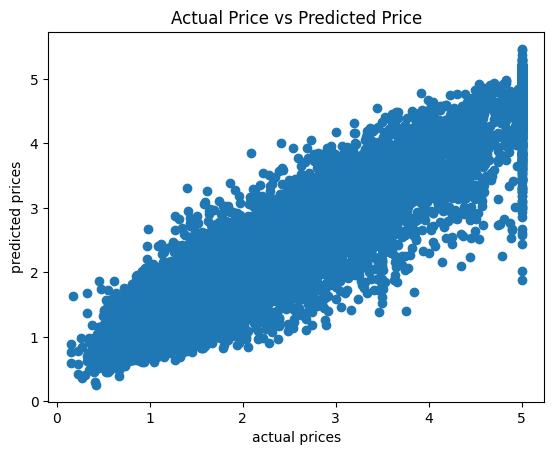

In [44]:
plt.scatter(y_train, training_data_prediction)
plt.xlabel('actual prices')
plt.ylabel('predicted prices')
plt.title('Actual Price vs Predicted Price')
plt.show()

Prediction on Test Data

In [42]:
test_data_prediction = model.predict(X_test)

In [43]:
# R squared error
score_1 = metrics.r2_score(y_test, test_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(y_test, test_data_prediction)

print('R Squared Error : ', score_1)
print('Mean Absolute Error : ', score_2)

R Squared Error :  0.6777709507505346
Mean Absolute Error :  0.4629861623248631
